# MedGuard AI — Step 2: XAI (Explainable AI)
### SHAP — Diabetes + Heart Disease Models
---
**Is notebook mein kya hoga:**
- Har model ke liye SHAP values calculate honge
- Feature importance charts banenge (global + per-patient)
- Ek patient ka complete explanation generate hoga
- Ye explanations baad mein frontend dashboard mein dikhenge

> Same folder mein rakho: `diabetes_model_v2.keras`, `diabetes_preprocessor_v2.pkl`, `diabetes_threshold_v2.json`, `diabetes.csv`, `heart_model_v2.pkl`, `heart_threshold_v2.json`, `heart_disease.csv`

In [25]:
# Cell 2 — Imports
import json, joblib, warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

shap.initjs()
print('SHAP version:', shap.__version__)
print('All imports OK!')

SHAP version: 0.51.0
All imports OK!


---
## PART 1 — Diabetes Model SHAP
### Global feature importance + Per-patient explanation

In [2]:
# Cell 3 — Load diabetes data + preprocess (same as training)
df = pd.read_csv('diabetes.csv')

# Feature engineering
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)
df['BMI_Age']         = df['BMI'] / (df['Age'] + 1)
df['Glucose_Insulin'] = df['Glucose'] * df['Insulin']
df['BP_Age']          = df['BloodPressure'] / (df['Age'] + 1)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

def cap_outliers_iqr(df, cols):
    df = df.copy()
    for c in cols:
        q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
        iqr = q3 - q1
        df[c] = df[c].clip(q1 - 1.5*iqr, q3 + 1.5*iqr)
    return df
X = cap_outliers_iqr(X, X.columns)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessor
preprocessor = joblib.load('diabetes_preprocessor_v2.pkl')
X_train_prep = preprocessor.transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# SMOTE (sirf train pe)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)

feature_names = X.columns.tolist()
print('Features:', feature_names)
print('Test samples:', len(X_test))

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_Age', 'Glucose_Insulin', 'BP_Age']
Test samples: 154


In [3]:
# Cell 4 — Load model + threshold
diabetes_model = tf.keras.models.load_model('diabetes_model_v2.keras')

with open('diabetes_threshold_v2.json') as f:
    THRESHOLD = json.load(f)['threshold']

print(f'Model loaded! Threshold: {THRESHOLD}')

# Wrapper function SHAP ke liye
def diabetes_predict(x):
    return diabetes_model.predict(x, verbose=0).ravel()

# Quick test
sample_pred = diabetes_predict(X_test_prep[:3])
print('Sample predictions:', sample_pred)

Model loaded! Threshold: 0.24
Sample predictions: [0.74486387 0.01089429 0.14930025]


In [4]:
# Cell 5 — SHAP values calculate karo (2-3 minutes)
print('SHAP explainer bana raha hai...')

# Background data — 100 samples se fast chalega
background = X_train_bal[:100]

explainer_d = shap.KernelExplainer(diabetes_predict, background)

# Test set ke 100 samples pe SHAP calculate karo
print('SHAP values calculate ho rahe hain... (thoda time lagega)')
shap_values_d = explainer_d.shap_values(X_test_prep[:100], nsamples=100)

print('SHAP calculation complete!')
print('Shape:', np.array(shap_values_d).shape)

SHAP explainer bana raha hai...
SHAP values calculate ho rahe hain... (thoda time lagega)


  0%|          | 0/100 [00:00<?, ?it/s]

SHAP calculation complete!
Shape: (100, 11)


=== DIABETES MODEL — Global Feature Importance ===


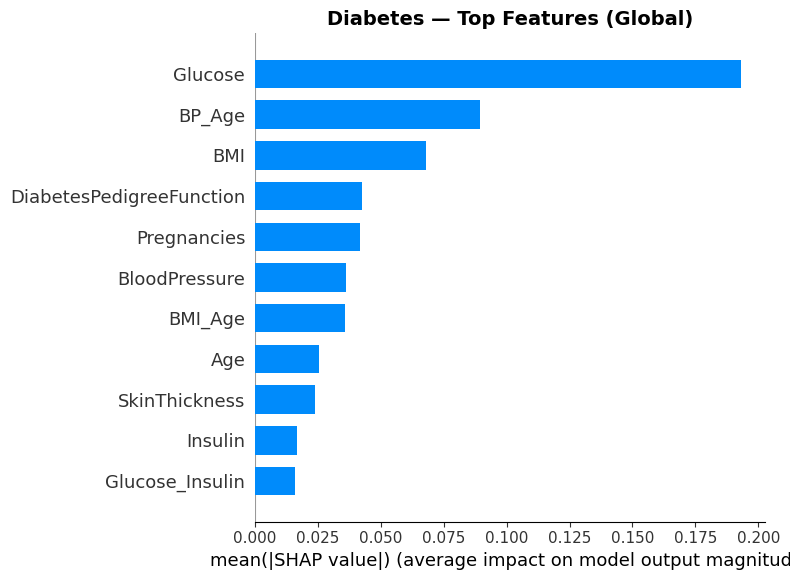

Saved: diabetes_shap_global.png


In [5]:
# Cell 6 — Global Feature Importance (Summary Plot)
print('=== DIABETES MODEL — Global Feature Importance ===')

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_d,
    X_test_prep[:100],
    feature_names=feature_names,
    show=False,
    plot_type='bar'
)
plt.title('Diabetes — Top Features (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diabetes_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diabetes_shap_global.png')

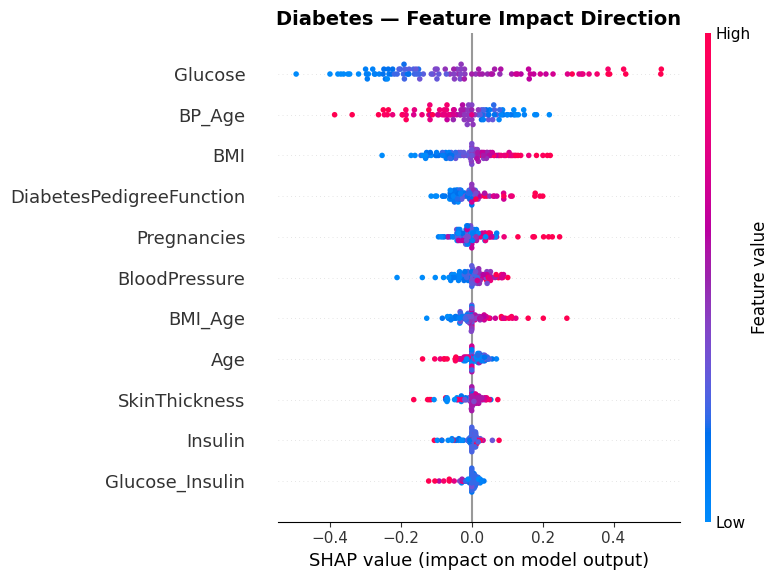

Red dot = high value = risk badhata hai
Blue dot = low value = risk kam karta hai


In [6]:
# Cell 7 — Beeswarm Plot (feature value ka impact)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_d,
    X_test_prep[:100],
    feature_names=feature_names,
    show=False
)
plt.title('Diabetes — Feature Impact Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diabetes_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
# Red = high feature value = high risk
# Blue = low feature value = low risk
print('Red dot = high value = risk badhata hai')
print('Blue dot = low value = risk kam karta hai')

In [7]:
# Cell 8 — Single Patient Explanation
# Pehla diabetic patient dhundo
diabetic_indices = np.where(y_test.values == 1)[0]
PATIENT_IDX = diabetic_indices[0]  # pehla diabetes patient

patient_data    = X_test_prep[PATIENT_IDX:PATIENT_IDX+1]
patient_prob    = diabetes_predict(patient_data)[0]
patient_pred    = int(patient_prob >= THRESHOLD)
patient_shap    = explainer_d.shap_values(patient_data, nsamples=200)
patient_actual  = y_test.values[PATIENT_IDX]

print(f'Patient Index  : {PATIENT_IDX}')
print(f'Actual Label   : {"Diabetic" if patient_actual==1 else "Not Diabetic"}')
print(f'Predicted Prob : {patient_prob:.4f}')
print(f'Prediction     : {"Diabetic" if patient_pred==1 else "Not Diabetic"} (threshold={THRESHOLD})')

# SHAP contribution per feature
shap_df = pd.DataFrame({
    'Feature'     : feature_names,
    'SHAP Value'  : patient_shap[0],
    'Feature Value': X_test.values[PATIENT_IDX]
}).sort_values('SHAP Value', key=abs, ascending=False)

print('\nTop risk contributors for this patient:')
print(shap_df.head(8).to_string(index=False))

  0%|          | 0/1 [00:00<?, ?it/s]

Patient Index  : 3
Actual Label   : Diabetic
Predicted Prob : 0.3832
Prediction     : Diabetic (threshold=0.24)

Top risk contributors for this patient:
                 Feature  SHAP Value  Feature Value
                     BMI   -0.148396      27.400000
                 Glucose   -0.096404     114.000000
DiabetesPedigreeFunction    0.087418       0.732000
             Pregnancies    0.066972       7.000000
                  BP_Age    0.043498       1.828571
           BloodPressure   -0.042736      64.000000
                 Insulin    0.017068            NaN
         Glucose_Insulin    0.013950            NaN


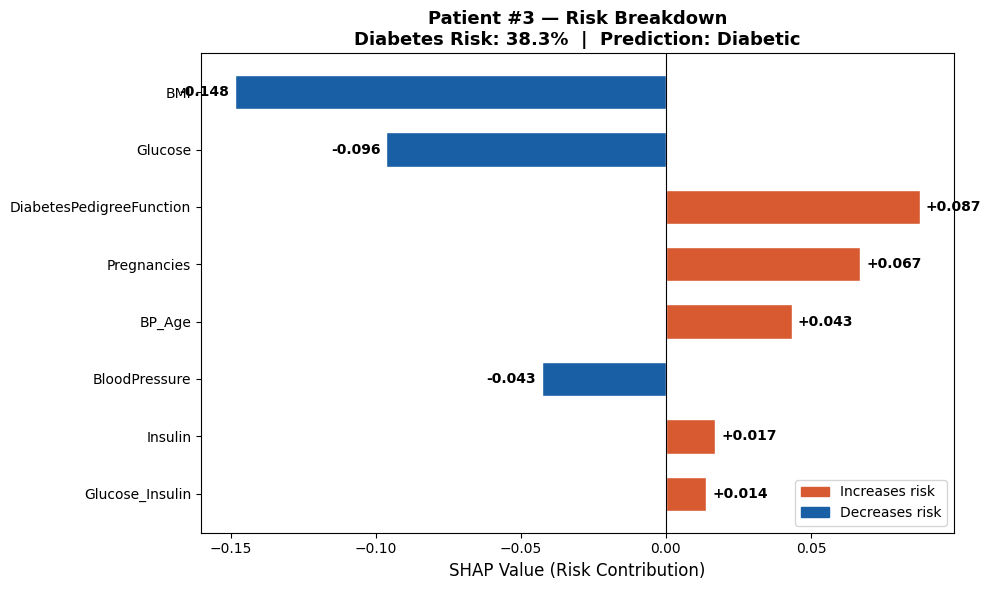

Saved: diabetes_patient_explanation.png


In [8]:
# Cell 9 — Patient Waterfall Chart (dashboard mein yahi dikhega)
top_n = 8
top_features = shap_df.head(top_n)
colors = ['#D85A30' if v > 0 else '#185FA5' for v in top_features['SHAP Value']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top_features['Feature'],
    top_features['SHAP Value'],
    color=colors,
    edgecolor='white',
    height=0.6
)

# Value labels
for bar, (_, row) in zip(bars, top_features.iterrows()):
    width = bar.get_width()
    label_x = width + 0.002 if width >= 0 else width - 0.002
    ha = 'left' if width >= 0 else 'right'
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f"+{width:.3f}" if width > 0 else f"{width:.3f}",
            va='center', ha=ha, fontsize=10, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Value (Risk Contribution)', fontsize=12)
ax.set_title(
    f'Patient #{PATIENT_IDX} — Risk Breakdown\n'
    f'Diabetes Risk: {patient_prob*100:.1f}%  |  Prediction: {"Diabetic" if patient_pred else "Not Diabetic"}',
    fontsize=13, fontweight='bold'
)
red_patch  = mpatches.Patch(color='#D85A30', label='Increases risk')
blue_patch = mpatches.Patch(color='#185FA5', label='Decreases risk')
ax.legend(handles=[red_patch, blue_patch], loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('diabetes_patient_explanation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diabetes_patient_explanation.png')

---
## PART 2 — Heart Disease Model SHAP
### (RandomForest — TreeExplainer use karega, bahut fast!)

In [9]:
# Cell 10 — Load heart data + model
df_h = pd.read_csv('heart_disease.csv')

important_cols = [
    'HeartDiseaseorAttack','HighBP','HighChol','CholCheck','BMI',
    'Smoker','Stroke','Diabetes','PhysActivity','Fruits','Veggies',
    'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','GenHlth',
    'MentHlth','PhysHlth','DiffWalk','Sex','Age','Education','Income'
]
df_h = df_h[important_cols].copy()

X_h = df_h.drop(columns=['HeartDiseaseorAttack'])
y_h = df_h['HeartDiseaseorAttack']

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42, stratify=y_h
)

# Load model + threshold
pipe_h = joblib.load('heart_model_v2.pkl')

with open('heart_threshold_v2.json') as f:
    H_THRESHOLD = json.load(f)['threshold']

h_feature_names = X_h.columns.tolist()
print(f'Model loaded! Threshold: {H_THRESHOLD}')
print(f'Test samples: {len(X_h_test)}')
print(f'Features: {h_feature_names}')

Model loaded! Threshold: 0.59
Test samples: 50736
Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [16]:
# Cell 11 — SHAP TreeExplainer (RandomForest ke liye — bahut fast!)
print('TreeExplainer bana raha hai...')

# Pipeline se sirf model extract karo
rf_model     = pipe_h.named_steps['model']
preprocessor_h = pipe_h.named_steps['preprocess'] if 'preprocess' in pipe_h.named_steps else pipe_h.named_steps['scaler']

# Test data preprocess karo
try:
    X_h_test_prep = preprocessor_h.transform(X_h_test)
except:
    # Agar pipeline mein direct scaler hai
    X_h_test_prep = X_h_test.values

# TreeExplainer — exact SHAP values, koi approximation nahi
explainer_h = shap.TreeExplainer(rf_model)
shap_values_h = explainer_h.shap_values(X_h_test_prep[:500])

# RandomForest binary: shap_values_h[1] = class 1 (heart disease)
shap_vals_disease = shap_values_h[:, :, 1]

print('Fixed shape:', shap_vals_disease.shape) 

print('SHAP complete!')
print('Shape:', shap_vals_disease.shape)

TreeExplainer bana raha hai...
Fixed shape: (500, 21)
SHAP complete!
Shape: (500, 21)


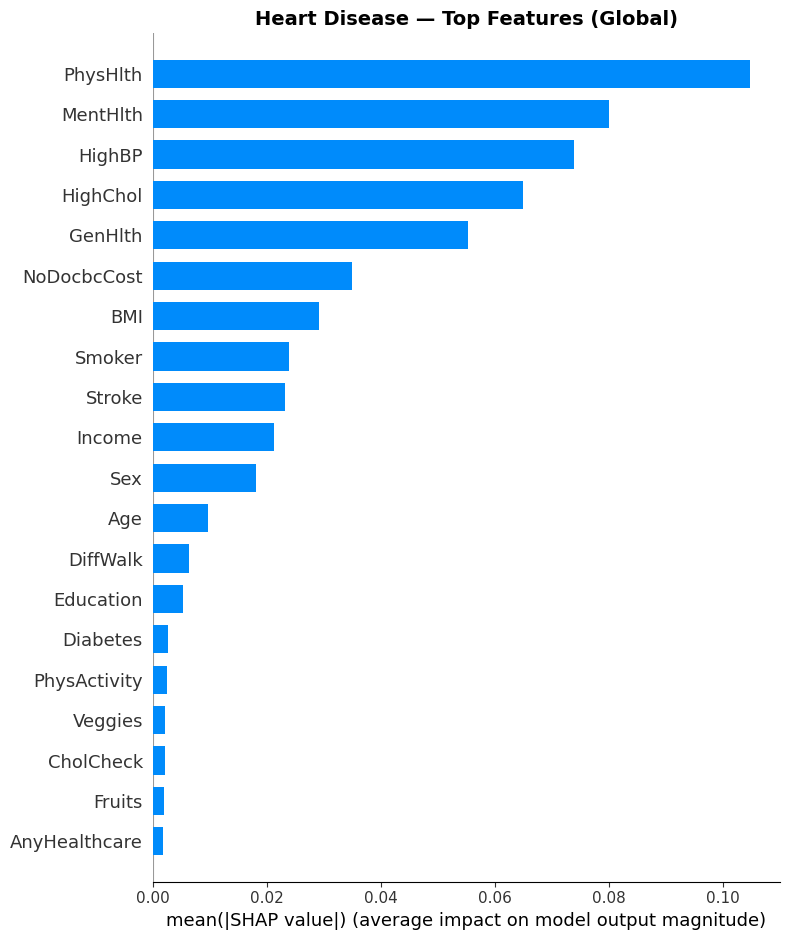

Saved: heart_shap_global.png


In [17]:
# Cell 12 — Global Feature Importance — Heart Disease
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_disease,
    X_h_test_prep[:500],
    feature_names=h_feature_names,
    show=False,
    plot_type='bar'
)
plt.title('Heart Disease — Top Features (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heart_shap_global.png')

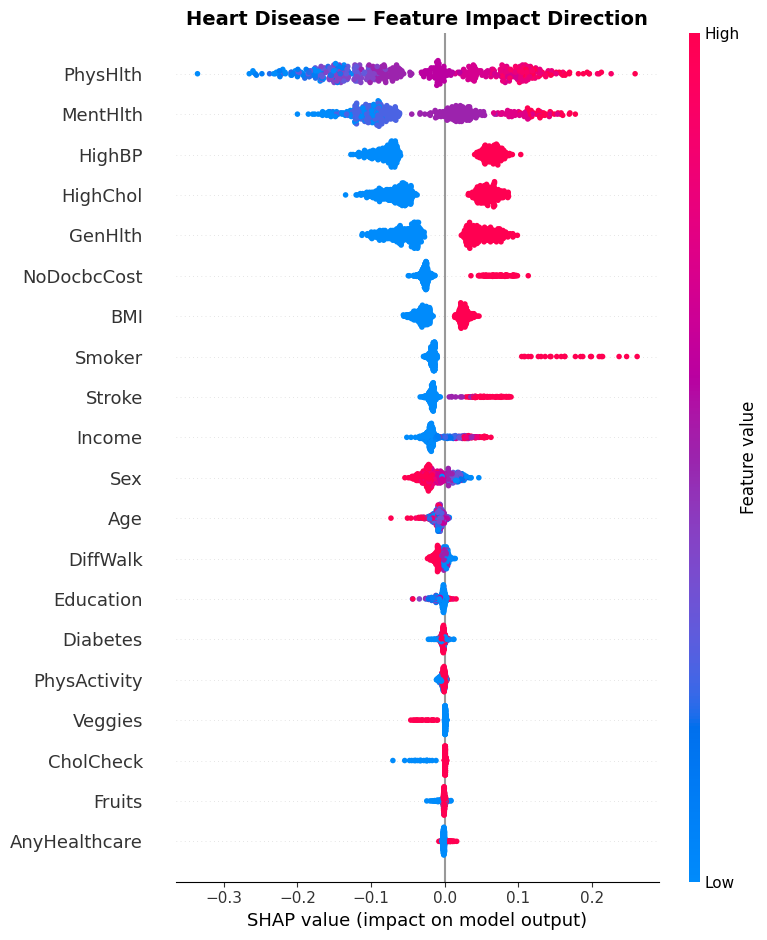

In [18]:
# Cell 13 — Beeswarm — Heart Disease
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_disease,
    X_h_test_prep[:500],
    feature_names=h_feature_names,
    show=False
)
plt.title('Heart Disease — Feature Impact Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# DEBUG — pehle yeh run karo
print('h_feature_names length:', len(h_feature_names))
print('patient_h_shap shape:', patient_h_shap.shape)
print('X_h_test row length:', len(X_h_test.values[H_PATIENT_IDX]))
print('shap_vals_disease shape:', np.array(shap_vals_disease).shape)
print('shap_vals_disease type:', type(shap_vals_disease))

h_feature_names length: 21
patient_h_shap shape: (42,)
X_h_test row length: 21
shap_vals_disease shape: (500, 21)
shap_vals_disease type: <class 'numpy.ndarray'>


In [20]:
# Cell 14 — Single Heart Patient Explanation (FIXED)
heart_indices = np.where(y_h_test.values == 1)[0]
H_PATIENT_IDX = heart_indices[0]

patient_h_data = X_h_test_prep[H_PATIENT_IDX:H_PATIENT_IDX+1]
patient_h_prob = pipe_h.predict_proba(
    X_h_test.iloc[H_PATIENT_IDX:H_PATIENT_IDX+1]
)[0][1]
patient_h_pred   = int(patient_h_prob >= H_THRESHOLD)
patient_h_actual = y_h_test.values[H_PATIENT_IDX]

patient_h_shap = shap_vals_disease[H_PATIENT_IDX] 

print(f'Patient Index  : {H_PATIENT_IDX}')
print(f'Actual Label   : {"Heart Disease" if patient_h_actual==1 else "No Disease"}')
print(f'Predicted Prob : {patient_h_prob:.4f}')
print(f'Prediction     : {"Heart Disease" if patient_h_pred==1 else "No Disease"}')
print(f'SHAP shape check: {patient_h_shap.shape} | Features: {len(h_feature_names)}')

shap_h_df = pd.DataFrame({
    'Feature'      : h_feature_names,
    'SHAP Value'   : patient_h_shap,          # ab 1D hai
    'Feature Value': X_h_test.values[H_PATIENT_IDX]
}).sort_values('SHAP Value', key=abs, ascending=False)

print('\nTop risk contributors:')
print(shap_h_df.head(8).to_string(index=False))

Patient Index  : 6
Actual Label   : Heart Disease
Predicted Prob : 0.8058
Prediction     : Heart Disease
SHAP shape check: (21,) | Features: 21

Top risk contributors:
    Feature  SHAP Value  Feature Value
     Smoker    0.136507            0.0
   MentHlth    0.077549           10.0
NoDocbcCost    0.058405            1.0
     HighBP    0.051414            1.0
   PhysHlth    0.046709           18.0
    GenHlth   -0.034937            4.0
        BMI   -0.034125           40.0
   HighChol    0.033808            1.0


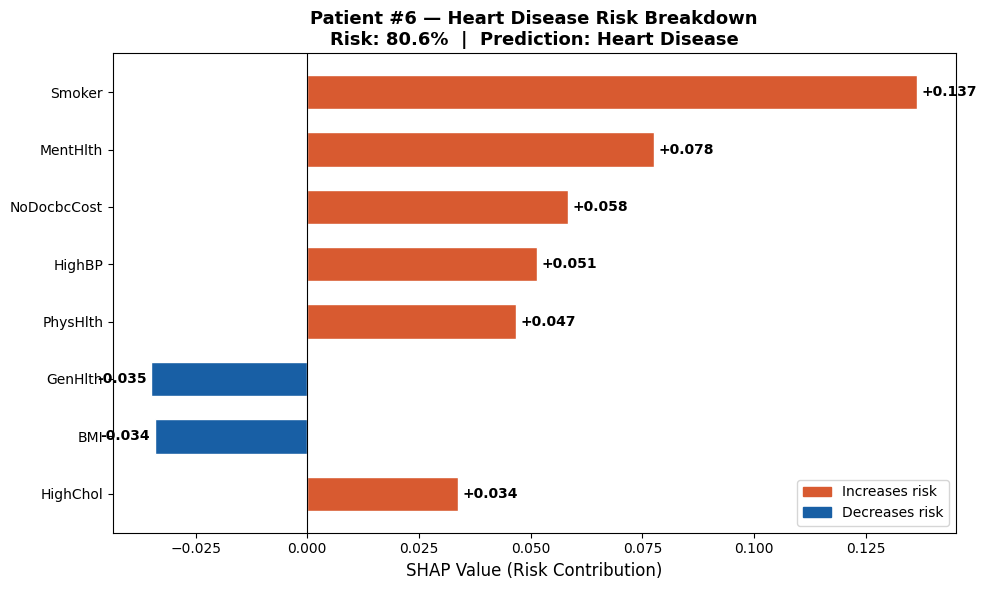

Saved: heart_patient_explanation.png


In [21]:
# Cell 15 — Heart Patient Waterfall Chart
top_h = shap_h_df.head(8)
colors_h = ['#D85A30' if v > 0 else '#185FA5' for v in top_h['SHAP Value']]

fig, ax = plt.subplots(figsize=(10, 6))
bars_h = ax.barh(
    top_h['Feature'],
    top_h['SHAP Value'],
    color=colors_h,
    edgecolor='white',
    height=0.6
)

for bar, (_, row) in zip(bars_h, top_h.iterrows()):
    width = bar.get_width()
    label_x = width + 0.001 if width >= 0 else width - 0.001
    ha = 'left' if width >= 0 else 'right'
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f"+{width:.3f}" if width > 0 else f"{width:.3f}",
            va='center', ha=ha, fontsize=10, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Value (Risk Contribution)', fontsize=12)
ax.set_title(
    f'Patient #{H_PATIENT_IDX} — Heart Disease Risk Breakdown\n'
    f'Risk: {patient_h_prob*100:.1f}%  |  Prediction: {"Heart Disease" if patient_h_pred else "No Disease"}',
    fontsize=13, fontweight='bold'
)
red_p  = mpatches.Patch(color='#D85A30', label='Increases risk')
blue_p = mpatches.Patch(color='#185FA5', label='Decreases risk')
ax.legend(handles=[red_p, blue_p], loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('heart_patient_explanation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heart_patient_explanation.png')

---
## PART 3 — Combined Risk Score + JSON Export
### (Frontend dashboard ke liye data ready karo)

In [22]:
# Cell 16 — Risk Score Engine
# Kisi bhi patient ka combined risk score nikalo

def get_patient_report(patient_idx):
    """Ek patient ka complete MedGuard AI report"""

    # Diabetes risk
    d_prob  = diabetes_predict(X_test_prep[patient_idx:patient_idx+1])[0]
    d_pred  = int(d_prob >= THRESHOLD)
    d_shap  = explainer_d.shap_values(X_test_prep[patient_idx:patient_idx+1], nsamples=100)[0]
    d_top   = sorted(zip(feature_names, d_shap), key=lambda x: abs(x[1]), reverse=True)[:5]

    # Heart risk — diabetes test set ke same index wala patient
    # (demo ke liye alag patient bhi ho sakta hai)
    h_prob = pipe_h.predict_proba(
        X_h_test.iloc[H_PATIENT_IDX:H_PATIENT_IDX+1]
    )[0][1]
    h_pred  = int(h_prob >= H_THRESHOLD)
    h_shap  = shap_vals_disease[H_PATIENT_IDX]
    h_top   = sorted(zip(h_feature_names, h_shap), key=lambda x: abs(x[1]), reverse=True)[:5]

    # Combined risk score (0-100)
    combined_score = round((d_prob * 0.5 + h_prob * 0.5) * 100, 1)
    zone = 'RED' if combined_score > 65 else 'YELLOW' if combined_score > 35 else 'GREEN'

    report = {
        'patient_idx'    : patient_idx,
        'risk_score'     : combined_score,
        'risk_zone'      : zone,
        'diabetes': {
            'probability'     : round(d_prob * 100, 1),
            'prediction'      : 'Diabetic' if d_pred else 'Not Diabetic',
            'top_factors'     : [{'feature': f, 'shap': round(s, 4)} for f, s in d_top]
        },
        'heart_disease': {
            'probability'     : round(h_prob * 100, 1),
            'prediction'      : 'Heart Disease' if h_pred else 'No Disease',
            'top_factors'     : [{'feature': f, 'shap': round(float(s), 4)} for f, s in h_top]
        }
    }
    return report

# Test karo
report = get_patient_report(PATIENT_IDX)

print('=' * 55)
print('  MEDGUARD AI — PATIENT REPORT')
print('=' * 55)
print(f"  Risk Score : {report['risk_score']} / 100")
print(f"  Risk Zone  : {report['risk_zone']}")
print(f"  Diabetes   : {report['diabetes']['probability']}% — {report['diabetes']['prediction']}")
print(f"  Heart      : {report['heart_disease']['probability']}% — {report['heart_disease']['prediction']}")
print()
print('  Top Diabetes Risk Factors:')
for f in report['diabetes']['top_factors']:
    arrow = '↑ RISK' if f['shap'] > 0 else '↓ safe'
    print(f"    {f['feature']:25s} {f['shap']:+.4f}  {arrow}")
print()
print('  Top Heart Risk Factors:')
for f in report['heart_disease']['top_factors']:
    arrow = '↑ RISK' if f['shap'] > 0 else '↓ safe'
    print(f"    {f['feature']:25s} {f['shap']:+.4f}  {arrow}")

  0%|          | 0/1 [00:00<?, ?it/s]

  MEDGUARD AI — PATIENT REPORT
  Risk Score : 59.4 / 100
  Risk Zone  : YELLOW
  Diabetes   : 38.29999923706055% — Diabetic
  Heart      : 80.6% — Heart Disease

  Top Diabetes Risk Factors:
    BMI                       -0.1411  ↓ safe
    Glucose                   -0.0998  ↓ safe
    DiabetesPedigreeFunction  +0.0875  ↑ RISK
    Pregnancies               +0.0630  ↑ RISK
    BloodPressure             -0.0433  ↓ safe

  Top Heart Risk Factors:
    Smoker                    +0.1365  ↑ RISK
    MentHlth                  +0.0775  ↑ RISK
    NoDocbcCost               +0.0584  ↑ RISK
    HighBP                    +0.0514  ↑ RISK
    PhysHlth                  +0.0467  ↑ RISK


In [26]:
# Cell 17 — JSON export (FIXED)
import json

# Numpy types ko Python types mein convert karo
def convert_to_serializable(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer,)):
            return int(obj)
        elif isinstance(obj, (np.floating,)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

with open('patient_report_sample.json', 'w') as f:
    json.dump(report, f, indent=2, cls=NumpyEncoder)

print('Saved: patient_report_sample.json')
print()
print('Files generated:')
output_files = [
    'diabetes_shap_global.png',
    'diabetes_shap_beeswarm.png', 
    'diabetes_patient_explanation.png',
    'heart_shap_global.png',
    'heart_shap_beeswarm.png',
    'heart_patient_explanation.png',
    'patient_report_sample.json'
]
for f in output_files:
    exists = os.path.exists(f)
    print(f"  {'OK' if exists else 'MISSING':6s} {f}")

print()
print('Step 2 Complete! Ab Step 3 (FastAPI Backend) ke liye ready!')

Saved: patient_report_sample.json

Files generated:
  OK     diabetes_shap_global.png
  OK     diabetes_shap_beeswarm.png
  OK     diabetes_patient_explanation.png
  OK     heart_shap_global.png
  OK     heart_shap_beeswarm.png
  OK     heart_patient_explanation.png
  OK     patient_report_sample.json

Step 2 Complete! Ab Step 3 (FastAPI Backend) ke liye ready!
